In [1]:
library(tidyverse)

# Load files
county   <- read_csv("data/county_data.csv")
census   <- read_csv("data/texas_census.csv")
brfss    <- read_csv("data/brfss_dataf.csv")  # replace with actual filename

# Step 1: join census to county (both are county-level)
df <- county %>%
  left_join(census, by = "County")

# Step 2: transpose BRFSS so it's PHR-level (one row per PHR)
brfss_wide <- brfss %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Step 3: join BRFSS to county data via PHR
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

# Check
glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")

write_csv(df_final, "data/combined_data.csv")

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'forcats' wurde unter R Version 4.4.1 erstellt"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows

Rows: 254
Columns: 174
$ County                           <chr> "Anderson", "Andrews", "Angelina", "A~
$ cve                              <dbl> 2.54, 1.91, 2.50, 2.06, 2.70, 5.24, 1~
$ outbreak                         <dbl> 0, 3, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0~
$ enrollment                       <dbl> 7808, 4209, 15649, 2913, 2110, 297, 9~
$ PHR                              <dbl> 4, 9, 5, 11, 2, 1, 8, 6, 1, 8, 7, 2, ~
$ pct_hispanic                     <dbl> 19.6, 57.5, 23.5, 27.1, 9.4, 12.0, 65~
$ pct_black                        <dbl> 18.6, 1.6, 12.1, 1.3, 1.5, 0.6, 1.2, ~
$ pct_white                        <dbl> 58.3, 57.7, 63.4, 76.9, 88.9, 89.9, 4~
$ pct_poverty                      <dbl> 13.5, 14.2, 11.5, 10.7, 4.5, 6.0, 13.~
$ pct_uninsured                    <dbl> 18.5, 22.4, 17.7, 12.8, 13.9, 4.2, 19~
$ pct_college                      <dbl> 15.4, 17.7, 17.9, 28.8, 25.4, 27.2, 1~
$ median_income                    <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, N~
$ pct_foreign_bor

In [9]:
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)

# ── 1. Load joined data ──────────────────────────────────────────────────────
df <- df_final

# Define outcome — cve is the response
outcome <- df$cve
offset_var <- log(df$enrollment)
PHR <- df$PHR

# ── 2. Build covariate matrix (drop ID/outcome columns) ──────────────────────
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

# ── 3. Spearman screen (p < 0.2) ────────────────────────────────────────────
spearman_screen <- function(X, y, threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)

# ── 4. Collinearity filter (|r| > 0.7) ──────────────────────────────────────
X_cand <- X_all[, candidates$variable, drop = FALSE]
cor_mat <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# ── 5. Remove rows with NA in outcome or offset ─────────────────────────────
valid <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)

outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]

# ── 6. Fit full model: cve ~ covariates + offset + (1|PHR) ──────────────────
formula_full <- as.formula(paste(
  "cve ~",
  paste(paste0("`", names(X_filtered_clean), "`"), collapse = " + "),
  "+ offset(log(enrollment)) + (1|PHR)"
))

fit_full <- glmmTMB(formula_full, data = bind_cols(
  cve = outcome_clean,
  enrollment = df$enrollment[valid],
  PHR = PHR_clean,
  X_filtered_clean
), family = gaussian())

# ── 7. Inspect and refit ────────────────────────────────────────────────────
summary(fit_full)

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 83 candidates
# A tibble: 83 x 3
   variable                        rho  p_value
   <chr>                         <dbl>    <dbl>
 1 pct_white                     0.556 5.03e-22
 2 pct_hispanic                 -0.551 1.50e-21
 3 pct_college                   0.390 1.19e-10
 4 Pain Med Not Rx              -0.353 7.35e- 9
 5 pct_poverty                  -0.299 1.26e- 6
 6 Difficulty Doing Errands Alo -0.281 5.59e- 6
 7 RxPainRiskEd Source           0.268 1.46e- 5
 8 Rx Opioid                     0.252 4.89e- 5
 9 BP Sharing                   -0.246 7.66e- 5
10 Diabetes Education           -0.246 7.66e- 5
# i 73 more rows
After collinearity filter: 28 variables


dropping columns from rank-deficient conditional model: `FOBT Past Yr`, `Kidney Disease`, `HIV Risk Behavior`, `Lifetime Asthma`, `Cervical Cancer Screening Pa`, `Menthol E-Cig`, `BP Location`, `Diabetes Eye Exam`, `Poor Mental Health 14+ Days`, `Chest CT or CAT Scan`, RemoveTeeth, ClnscpySgmscpy, `HIV-AIDS Test`, `Frequency of Smoking`



 Family: gaussian  ( identity )
Formula:          
cve ~ pct_white + pct_college + `Pain Med Not Rx` + pct_poverty +  
    `RxPainRiskEd Source` + `Diabetes Education` + pct_uninsured +  
    `Leftover Pain Meds` + `Ever Had Blood Stool Test` + `Fair or Poor Health` +  
    `Skin Cancer` + `Menthol Cig` + `Heavy Drinking` + `Difficulty Concentrating` +  
    `FOBT Past Yr` + `Kidney Disease` + `HIV Risk Behavior` +  
    `Lifetime Asthma` + `Cervical Cancer Screening Pa` + `Menthol E-Cig` +  
    `BP Location` + `Diabetes Eye Exam` + `Poor Mental Health 14+ Days` +  
    `Chest CT or CAT Scan` + RemoveTeeth + ClnscpySgmscpy + `HIV-AIDS Test` +  
    `Frequency of Smoking` + offset(log(enrollment)) + (1 | PHR)
Data: bind_cols(cve = outcome_clean, enrollment = df$enrollment[valid],  
    PHR = PHR_clean, X_filtered_clean)

      AIC       BIC    logLik -2*log(L)  df.resid 
   1092.0    1151.8    -529.0    1058.0       232 

Random effects:

Conditional model:
 Groups   Name        Varian

In [20]:
# ── 5. LASSO variable selection ──────────────────────────────────────────────
valid <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)

outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]

X_mat <- model.matrix(~ . - 1, data = X_filtered_clean)

cv_fit <- cv.glmnet(
  x = X_mat,
  y = outcome_clean,
  offset = offset_clean,
  family = "gaussian",
  alpha = 1
)

selected_coef <- coef(cv_fit, s = "lambda.min")
selected_vars <- rownames(selected_coef)[
  selected_coef[, 1] != 0 &
    !grepl("Intercept", rownames(selected_coef))
]
selected_vars <- selected_vars[!grepl("factor\\(PHR", selected_vars)]
cat("Final selected vars:\n")
print(selected_vars)

selected_coef <- coef(cv_fit, s = "lambda.min")  # less aggressive than lambda.1se
selected_vars <- rownames(selected_coef)[
  selected_coef[, 1] != 0 &
  !grepl("Intercept", rownames(selected_coef))
]
selected_vars <- selected_vars[!grepl("factor\\(PHR", selected_vars)]
cat("Final selected vars:\n")
print(selected_vars)

Final selected vars:
[1] "pct_white"                      "`Fair or Poor Health`"         
[3] "`Heavy Drinking`"               "`FOBT Past Yr`"                
[5] "`Lifetime Asthma`"              "`Cervical Cancer Screening Pa`"
[7] "`Poor Mental Health 14+ Days`"  "`HIV-AIDS Test`"               
Final selected vars:
[1] "pct_white"                      "`Fair or Poor Health`"         
[3] "`Heavy Drinking`"               "`FOBT Past Yr`"                
[5] "`Lifetime Asthma`"              "`Cervical Cancer Screening Pa`"
[7] "`Poor Mental Health 14+ Days`"  "`HIV-AIDS Test`"               


Boruta performed 99 iterations in 17.21855 secs.
 8 attributes confirmed important: Diabetes Eye Exam, Ever Had Blood
Stool Test, Pain Med Not Rx, RxPainRiskEd Source, pct_college and 3
more;
 13 attributes confirmed unimportant: Cervical Cancer Screening Pa,
Chest CT or CAT Scan, ClnscpySgmscpy, Difficulty Concentrating, Fair or
Poor Health and 8 more;
 7 tentative attributes left: BP Location, Diabetes Education, FOBT
Past Yr, Frequency of Smoking, Lifetime Asthma and 2 more;


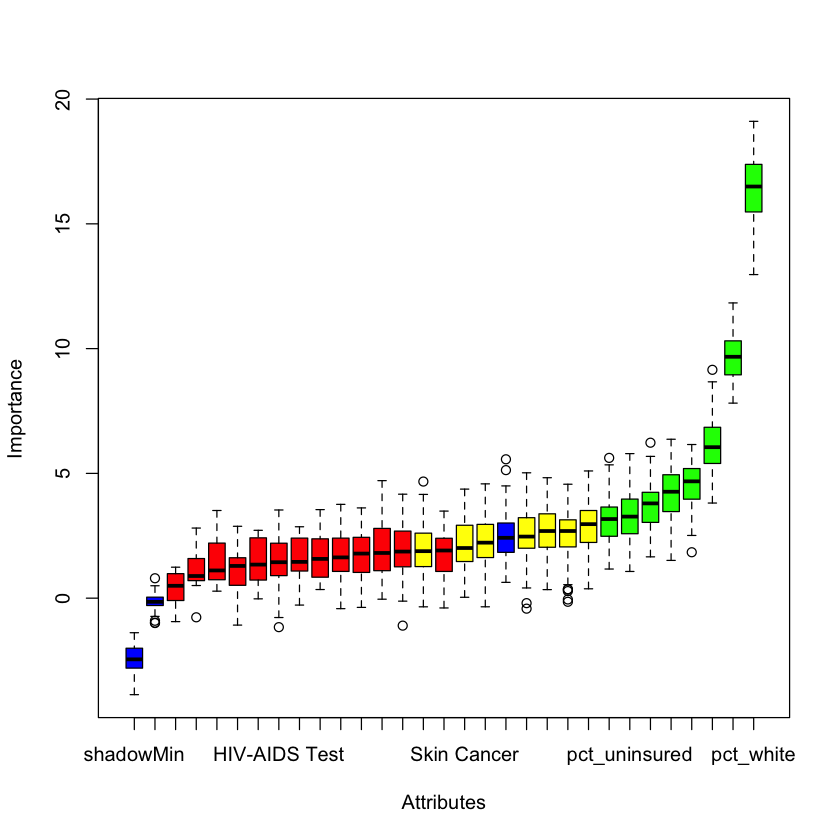

In [13]:
library(Boruta)
boruta_fit <- Boruta(x = X_filtered_clean, y = outcome_clean, maxRuns = 100)
print(boruta_fit)
plot(boruta_fit)

# 最终选择的变量
selected_vars <- getSelectedAttributes(boruta_fit, withTentative = FALSE)

In [19]:
# alpha=0.5 是中间值，0=纯Ridge，1=纯LASSO
cv_fit <- cv.glmnet(X_mat, outcome_clean,
                    alpha = 0,   # ← 改这里
                    family = "gaussian",
                    offset = offset_clean,
                    penalty.factor = pf,
                    nfolds = 10)
plot(cv_fit)
selected_coef <- coef(cv_fit, s = "lambda.1se")
selected_vars <- rownames(selected_coef)[
  selected_coef[, 1] != 0 &
  !grepl("Intercept", rownames(selected_coef))
]
selected_vars <- selected_vars[!grepl("factor\\(PHR", selected_vars)]
cat("Final selected vars:\n")
print(selected_vars)

ERROR: Error in glmnet(x, y, weights = weights, offset = offset, lambda = lambda, : the length of penalty.factor does not match the number of variables


In [21]:
boruta_final <- TentativeRoughFix(boruta_fit)
print(boruta_final)
selected_vars <- getSelectedAttributes(boruta_final, withTentative = FALSE)
print(selected_vars)

Boruta performed 99 iterations in 17.21855 secs.
Tentatives roughfixed over the last 99 iterations.
 12 attributes confirmed important: BP Location, Diabetes Education,
Diabetes Eye Exam, Ever Had Blood Stool Test, Frequency of Smoking and
7 more;
 16 attributes confirmed unimportant: Cervical Cancer Screening Pa,
Chest CT or CAT Scan, ClnscpySgmscpy, Difficulty Concentrating, FOBT
Past Yr and 11 more;
 [1] "pct_white"                 "pct_college"              
 [3] "Pain Med Not Rx"           "pct_poverty"              
 [5] "RxPainRiskEd Source"       "Diabetes Education"       
 [7] "pct_uninsured"             "Ever Had Blood Stool Test"
 [9] "Menthol Cig"               "BP Location"              
[11] "Diabetes Eye Exam"         "Frequency of Smoking"     


In [23]:
X_boruta <- model.matrix(~ . - 1, data = X_filtered_clean[, selected_vars, drop = FALSE])

cv_fit <- cv.glmnet(
  x = X_boruta,
  y = outcome_clean,
  family = "gaussian",
  alpha = 1
)

lasso_coef <- coef(cv_fit, s = "lambda.1se")
final_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
cat("Final vars (Boruta + LASSO):\n")
print(final_vars)

Final vars (Boruta + LASSO):
[1] "pct_white"


Final vars: 1 
[1] "pct_white"


 Family: gaussian  ( identity )
Formula:          cve ~ pct_white + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    975.1     989.2    -483.6     967.1       245 

Random effects:

Conditional model:
 Groups   Name        Variance Std.Dev.
 PHR      (Intercept) 0.1188   0.3446  
 Residual             2.7651   1.6629  
Number of obs: 249, groups:  PHR, 11

Dispersion estimate for gaussian family (sigma^2): 2.77 

Conditional model:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.153943   0.466878  -2.472   0.0135 *  
pct_white    0.061965   0.006993   8.860   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Warning message:
"Paket 'DHARMa' wurde unter R Version 4.4.1 erstellt"
This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')



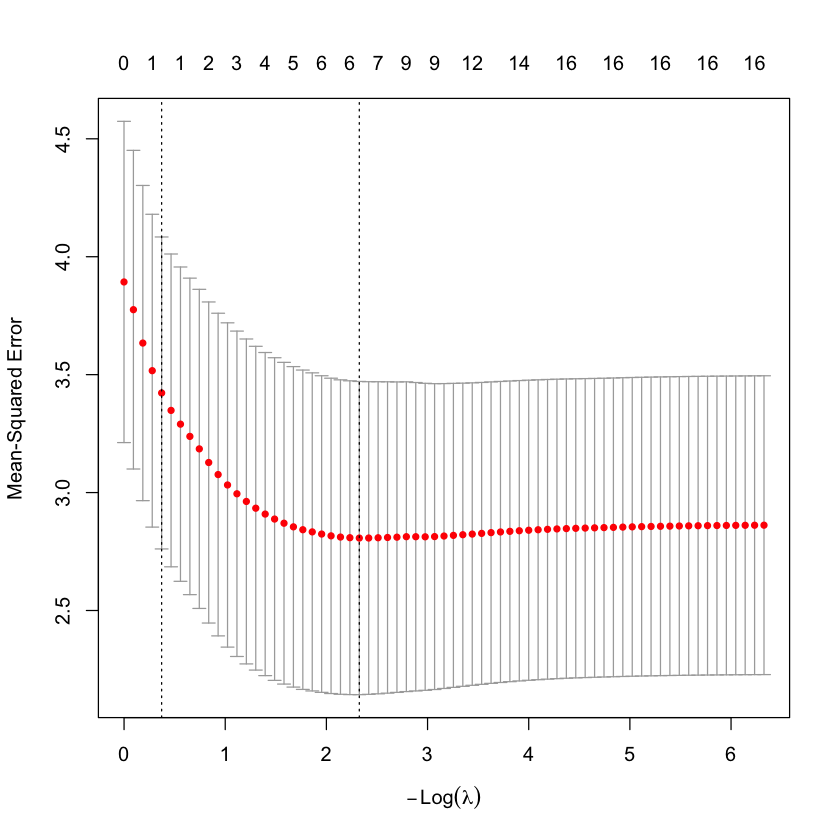

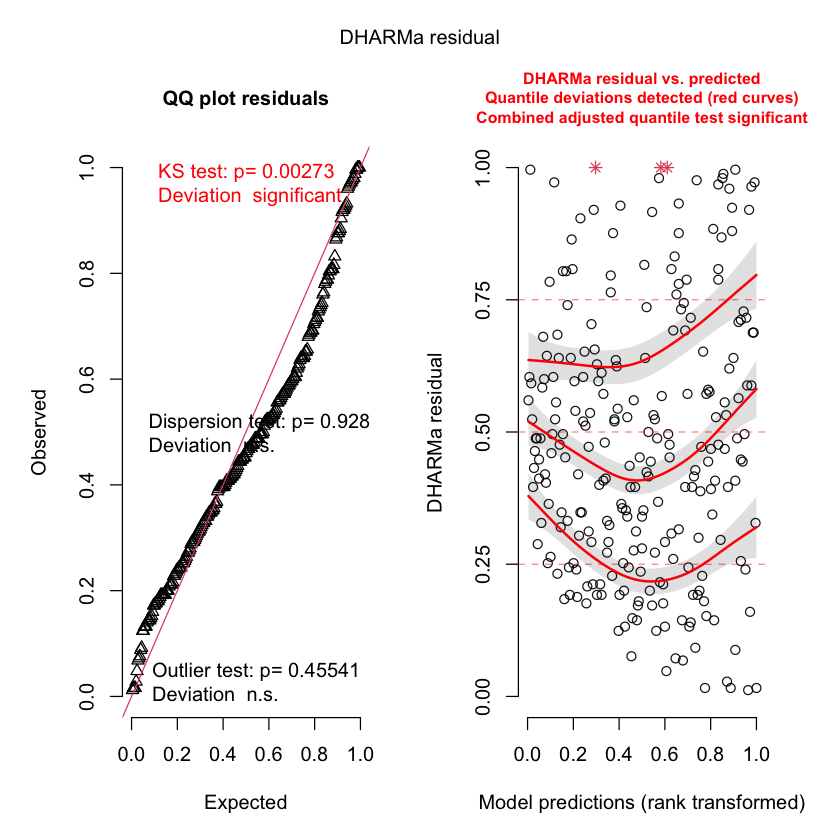

In [24]:
# ── LASSO variable selection (tight: lambda.1se) ────────────────────────────
valid <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)

outcome_clean    <- outcome[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]

X_mat <- model.matrix(~ . - 1, data = X_filtered_clean)

cv_fit <- cv.glmnet(
  x = X_mat,
  y = outcome_clean,
  family = "gaussian",
  alpha = 1
)

plot(cv_fit)

lasso_coef <- coef(cv_fit, s = "lambda.1se")
final_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
cat("Final vars:", length(final_vars), "\n")
print(final_vars)

# ── Fit glmmTMB ─────────────────────────────────────────────────────────────
model_df <- bind_cols(
  cve = outcome_clean,
  PHR = PHR_clean,
  X_filtered_clean[, final_vars, drop = FALSE]
)

formula_final <- as.formula(paste(
  "cve ~",
  paste(paste0("`", final_vars, "`"), collapse = " + "),
  "+ (1|PHR)"
))

fit_final <- glmmTMB(formula_final, data = model_df, family = gaussian())
summary(fit_final)

# ── Residuals ────────────────────────────────────────────────────────────────
library(DHARMa)
sim <- simulateResiduals(fit_final)
plot(sim)

In [14]:
df_model <- bind_cols(
  outcome    = outcome_clean,
  enrollment = df$enrollment[valid],
  PHR        = PHR_clean,
  X_filtered_clean[, selected_vars, drop = FALSE]
)

formula <- as.formula(paste(
  "outcome ~", paste(paste0("`", selected_vars, "`"), collapse = " + "),
  "+ offset(log(enrollment)) + (1|PHR)"
))

fit <- glmmTMB(formula, data = df_model, family = gaussian())
summary(fit)

 Family: gaussian  ( identity )
Formula:          
outcome ~ pct_white + pct_college + `Pain Med Not Rx` + pct_poverty +  
    `RxPainRiskEd Source` + pct_uninsured + `Ever Had Blood Stool Test` +  
    `Diabetes Eye Exam` + offset(log(enrollment)) + (1 | PHR)
Data: df_model

      AIC       BIC    logLik -2*log(L)  df.resid 
   1103.3    1142.0    -540.7    1081.3       238 

Random effects:

Conditional model:
 Groups   Name        Variance Std.Dev.
 PHR      (Intercept) 0.4498   0.6707  
 Residual             4.2765   2.0680  
Number of obs: 249, groups:  PHR, 11

Dispersion estimate for gaussian family (sigma^2): 4.28 

Conditional model:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -16.169038   5.125770  -3.154  0.00161 ** 
pct_white                     0.104738   0.010288  10.180  < 2e-16 ***
pct_college                  -0.016223   0.018208  -0.891  0.37294    
`Pain Med Not Rx`             0.513877   0.286522   1.793  0.0728

In [16]:
fit2 <- glmmTMB(outcome ~ pct_white + `RxPainRiskEd Source` + 
                `Diabetes Education` + `Ever Had Blood Stool Test` +
                `Menthol Cig` + `BP Location` + `Diabetes Eye Exam` +
                `Frequency of Smoking` +
                offset(log(enrollment)) + (1|PHR),
                data = df_model, family = gaussian())
summary(fit2)
AIC(fit, fit2)  # confirm fit2 is not worse

ERROR: Error in eval(predvars, data, env): Objekt 'Diabetes Education' nicht gefunden


In [18]:

library(glmnet)

# Ridge = alpha 0
cv_ridge <- cv.glmnet(
  X_mat, outcome_clean,
  alpha          = 0,
  family         = "gaussian",
  offset         = offset_clean,
  penalty.factor = pf,
  nfolds         = 10
)

plot(cv_ridge)

# Extract coefficients by magnitude
ridge_coef <- coef(cv_ridge, s = "lambda.min")
ridge_coef_df <- data.frame(
  variable = rownames(ridge_coef),
  estimate = as.numeric(ridge_coef)
) %>%
  filter(!grepl("Intercept|factor\\(PHR", variable)) %>%
  arrange(desc(abs(estimate)))

print(ridge_coef_df)

# Keep top 10 by magnitude
selected_vars_ridge <- ridge_coef_df %>%
  slice_head(n = 10) %>%
  pull(variable)

cat("Ridge selected:\n")
print(selected_vars_ridge)

# Build model data
df_model_ridge <- bind_cols(
  outcome    = outcome_clean,
  enrollment = df$enrollment[valid],
  PHR        = PHR_clean,
  X_filtered_clean[, selected_vars_ridge, drop = FALSE]
)

# Final model
formula_ridge <- as.formula(paste(
  "outcome ~",
  paste(paste0("`", selected_vars_ridge, "`"), collapse = " + "),
  "+ offset(log(enrollment)) + (1|PHR)"
))

fit_ridge <- glmmTMB(formula_ridge, data = df_model_ridge, family = gaussian())
summary(fit_ridge)

# Compare AIC
AIC(fit2, fit_ridge)

ERROR: Error in glmnet(x, y, weights = weights, offset = offset, lambda = lambda, : the length of penalty.factor does not match the number of variables


Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (7): pct_hispanic, pct_black, pct_white, pct_poverty, pct_uninsured, pct...
lgl (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 392 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (12): Sheet, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show

BRFSS indicators before pre-filter: 392 
BRFSS indicators after pre-filter  (<U+2265> 7 valid PHRs): 309 
Rows: 254
Columns: 322
$ County                                                     <chr> "Anderson",~
$ cve                                                        <dbl> 2.54, 1.91,~
$ outbreak                                                   <dbl> 0, 3, 0, 0,~
$ enrollment                                                 <dbl> 7808, 4209,~
$ PHR                                                        <dbl> 4, 9, 5, 11~
$ pct_hispanic                                               <dbl> 19.6, 57.5,~
$ pct_black                                                  <dbl> 18.6, 1.6, ~
$ pct_white                                                  <dbl> 58.3, 57.7,~
$ pct_poverty                                                <dbl> 13.5, 14.2,~
$ pct_uninsured                                              <dbl> 18.5, 22.4,~
$ pct_college                                                <dbl> 15.4

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 151 candidates
# A tibble: 151 x 3
   variable                              rho  p_value
   <chr>                               <dbl>    <dbl>
 1 pct_white                           0.556 5.03e-22
 2 pct_hispanic                       -0.551 1.50e-21
 3 pct_college                         0.390 1.19e-10
 4 pct_poverty                        -0.299 1.26e- 6
 5 Last Smoked - 10+ years             0.295 1.69e- 6
 6 Rx Opioid - No                     -0.284 4.28e- 6
 7 Difficulty Doing Errands Alo - Yes -0.281 5.59e- 6
 8 RxPainRiskEd Source - No           -0.278 6.83e- 6
 9 Stroke - No                        -0.269 1.44e- 5
10 RxPainRiskEd Source - Yes           0.268 1.46e- 5
# i 141 more rows
After collinearity filter: 27 variables
Boruta performed 99 iterations in 19.13285 secs.
Tentatives roughfixed over the last 99 iterations.
 13 attributes confirmed important: Cervical Cancer Screening - Yes,
E-Cig Status - Never used e-cigs, FOBT Past Yr IA - Yes, Frequency 

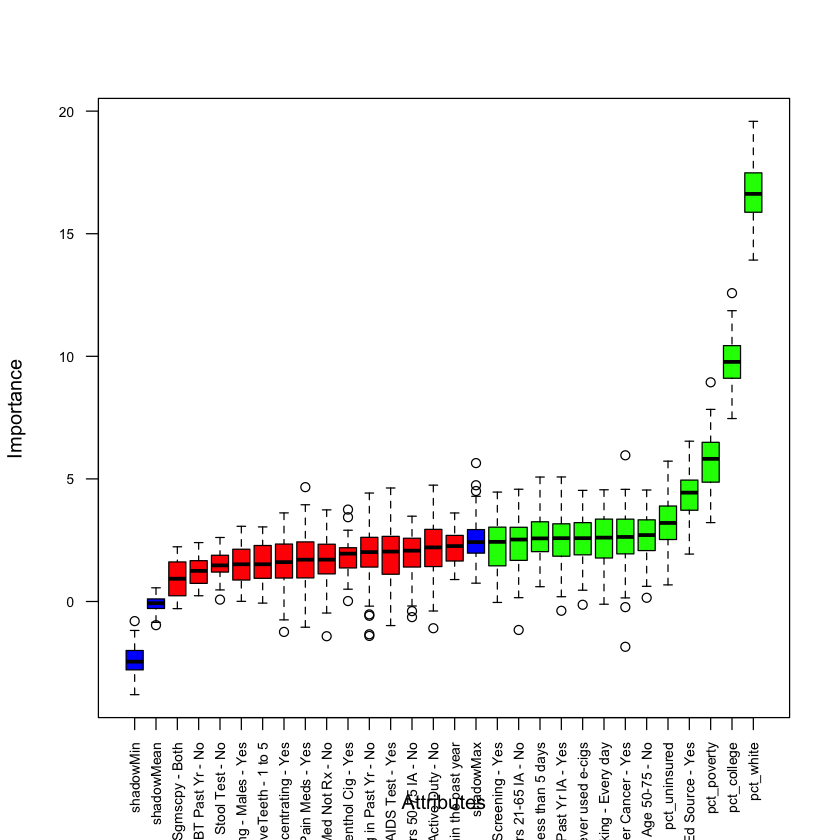

Final selected vars (Boruta + LASSO): 2 
[1] "pct_white"   "pct_college"


 Family: beta  ( logit )
Formula:          cve_prop ~ pct_white + pct_college + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
  -1458.5   -1440.9     734.3   -1468.5       249 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 0.01188  0.109   
Number of obs: 254, groups:  PHR, 11

Dispersion parameter for beta family ():  124 

Conditional model:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.223813   0.172675 -30.252  < 2e-16 ***
pct_white    0.018645   0.002197   8.486  < 2e-16 ***
pct_college  0.022007   0.003419   6.437 1.22e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

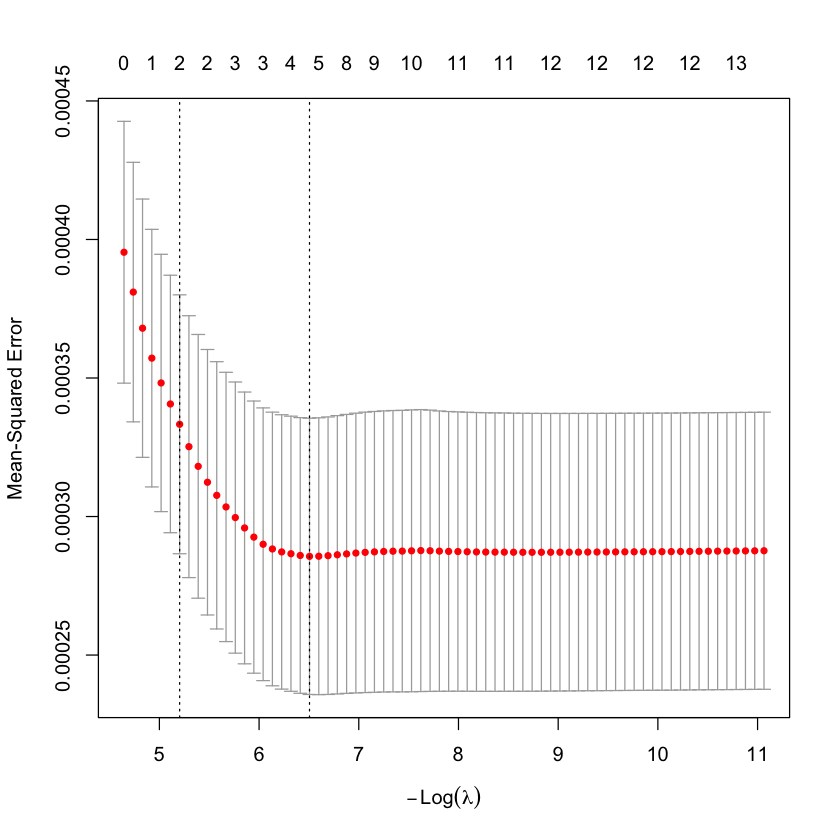

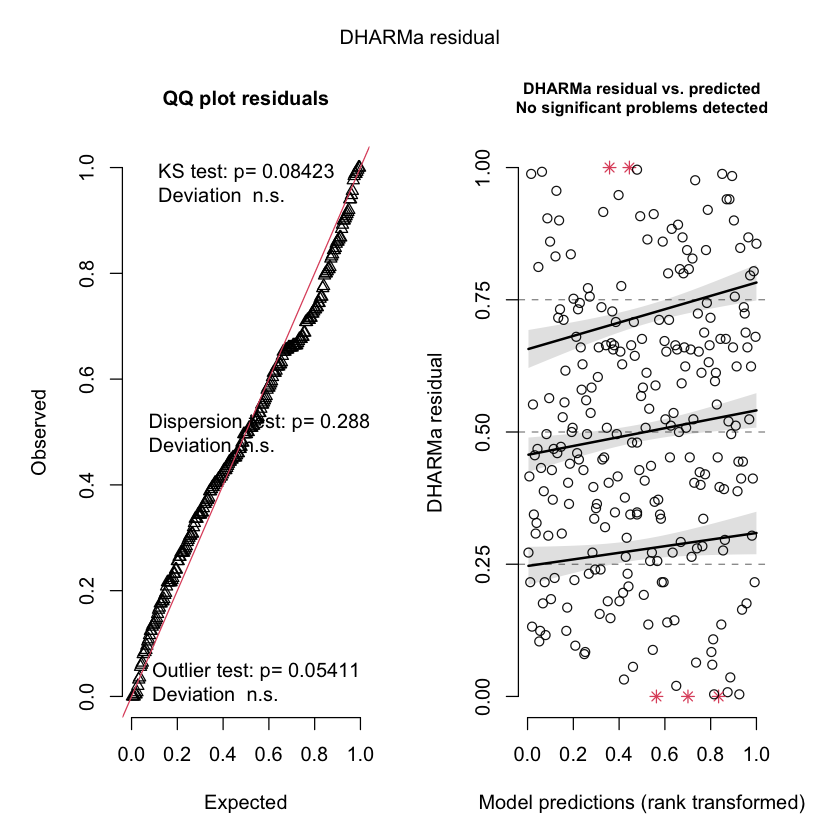

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# BRFSS Variable Selection Pipeline
# Outcome: CVE rate (county-level vaccine exemption rate, 0–100)
# Model:   Beta regression with PHR random intercept via glmmTMB
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(Boruta)
library(DHARMa)


# ── 0. Helper: Smithson & Verkuilen (2006) proportion transformation ─────────
# Beta regression requires y ∈ (0, 1) strictly — no exact 0s or 1s.
# This transformation compresses [0, 1] to (0, 1) using sample size n.
sv_transform <- function(y, n = length(y)) {
  (y * (n - 1) + 0.5) / n
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Data Loading & Merging
# ══════════════════════════════════════════════════════════════════════════════

county <- read_csv("data/county_data.csv")
census <- read_csv("data/texas_census.csv")
brfss  <- read_csv("data/brfss_all_categories.csv")  # Sheet = "Indicator - Category"

# Join census to county (both county-level)
df <- county %>%
  left_join(census, by = "County")

# Transpose BRFSS from wide-by-PHR to one row per PHR.
# "R" = suppressed (small sample, unreliable) → NA
# "N" = not asked in this PHR (structural)      → NA
# Both become NA numerically, but we track R-counts to pre-filter sparse indicators.
MIN_VALID_PHR <- 7   # drop any indicator with fewer than this many non-NA PHRs

brfss_long <- brfss %>%
  mutate(across(-Sheet, ~ na_if(as.character(.), "N")),
         across(-Sheet, ~ na_if(as.character(.), "R")))

# Count valid PHRs per indicator
valid_phr_counts <- brfss_long %>%
  rowwise() %>%
  mutate(n_valid = sum(!is.na(c_across(-Sheet)))) %>%
  ungroup() %>%
  select(Sheet, n_valid)

kept_indicators <- valid_phr_counts %>%
  filter(n_valid >= MIN_VALID_PHR) %>%
  pull(Sheet)

cat("BRFSS indicators before pre-filter:", nrow(brfss_long), "\n")
cat("BRFSS indicators after pre-filter  (≥", MIN_VALID_PHR, "valid PHRs):",
    length(kept_indicators), "\n")

brfss_wide <- brfss_long %>%
  filter(Sheet %in% kept_indicators) %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Join BRFSS (PHR-level) to county data
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")
write_csv(df_final, "data/combined_data.csv")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Outcome & Covariate Preparation
# ══════════════════════════════════════════════════════════════════════════════

df <- df_final

# CVE is a rate (0–100). Convert to proportion, then apply S-V transform.
cat("CVE zeros:", sum(df$cve == 0, na.rm = TRUE), "/", sum(!is.na(df$cve)), "\n")

cve_prop <- sv_transform(df$cve / 100)   # now strictly in (0, 1)
PHR      <- df$PHR

# Build covariate matrix (drop ID / outcome / offset columns)
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Spearman Screen  (p < 0.20)
# ══════════════════════════════════════════════════════════════════════════════

spearman_screen <- function(X, y, threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, cve_prop)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Collinearity Filter  (|r| > 0.70)
# ══════════════════════════════════════════════════════════════════════════════

X_cand    <- X_all[, candidates$variable, drop = FALSE]
cor_mat   <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# Remove rows where outcome is NA
valid            <- !is.na(cve_prop)
outcome_clean    <- cve_prop[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Variable Selection — Boruta → LASSO
# ══════════════════════════════════════════════════════════════════════════════

# ── 5a. Boruta ───────────────────────────────────────────────────────────────
set.seed(42)
boruta_fit   <- Boruta(x = X_filtered_clean, y = outcome_clean, maxRuns = 100)
boruta_final <- TentativeRoughFix(boruta_fit)
print(boruta_final)
plot(boruta_final, las = 2, cex.axis = 0.7)

boruta_vars <- getSelectedAttributes(boruta_final, withTentative = FALSE)
cat("Boruta selected:", length(boruta_vars), "variables\n")
print(boruta_vars)

# ── 5b. LASSO on Boruta-selected variables ───────────────────────────────────
X_boruta <- model.matrix(~ . - 1,
                         data = X_filtered_clean[, boruta_vars, drop = FALSE])

set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_boruta,
  y      = outcome_clean,
  family = "gaussian",   # LASSO screening step — gaussian OK here
  alpha  = 1
)
plot(cv_lasso)

lasso_coef  <- coef(cv_lasso, s = "lambda.1se")
final_vars  <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
cat("Final selected vars (Boruta + LASSO):", length(final_vars), "\n")
print(final_vars)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Final Model — Beta Regression with PHR Random Intercept
# ══════════════════════════════════════════════════════════════════════════════

# NOTE: CVE is already a rate → no offset needed.
#       beta_family() requires outcome strictly in (0, 1) — handled in Section 2.

if (length(final_vars) == 0) {
  # No BRFSS variable survived — intercept-only + random effect
  message("No BRFSS covariates survived selection. Fitting intercept-only model.")
  model_df <- tibble(cve_prop = outcome_clean, PHR = factor(PHR_clean))

  fit_final <- glmmTMB(cve_prop ~ 1 + (1 | PHR),
                       data   = model_df,
                       family = beta_family())
} else {
  model_df <- bind_cols(
    cve_prop = outcome_clean,
    PHR      = factor(PHR_clean),
    X_filtered_clean[, final_vars, drop = FALSE]
  )

  formula_final <- as.formula(paste(
    "cve_prop ~",
    paste(paste0("`", final_vars, "`"), collapse = " + "),
    "+ (1 | PHR)"
  ))

  fit_final <- glmmTMB(formula_final, data = model_df, family = beta_family())
}

summary(fit_final)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Diagnostics
# ══════════════════════════════════════════════════════════════════════════════

sim <- simulateResiduals(fit_final)
plot(sim)

Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (7): pct_hispanic, pct_black, pct_white, pct_poverty, pct_uninsured, pct...
lgl (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 392 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (12): Sheet, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show

BRFSS indicators before pre-filter: 392 
BRFSS indicators after pre-filter  (<U+2265> 7 valid PHRs): 309 
Rows: 254
Columns: 322
$ County                                                     <chr> "Anderson",~
$ cve                                                        <dbl> 2.54, 1.91,~
$ outbreak                                                   <dbl> 0, 3, 0, 0,~
$ enrollment                                                 <dbl> 7808, 4209,~
$ PHR                                                        <dbl> 4, 9, 5, 11~
$ pct_hispanic                                               <dbl> 19.6, 57.5,~
$ pct_black                                                  <dbl> 18.6, 1.6, ~
$ pct_white                                                  <dbl> 58.3, 57.7,~
$ pct_poverty                                                <dbl> 13.5, 14.2,~
$ pct_uninsured                                              <dbl> 18.5, 22.4,~
$ pct_college                                                <dbl> 15.4

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 199 candidates
# A tibble: 199 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 18

Fewer than 2 Boruta-selected variables; skipping LASSO, keeping Boruta selection.



Final selected vars (Boruta + LASSO): 1 
[1] "pct_uninsured"


 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + pct_uninsured + offset(log(enrollment)) + (1 |      PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    378.4     396.0    -184.2     368.4       244 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 7.739    2.782   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.159 

Conditional model:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -14.81834    1.63627  -9.056  < 2e-16 ***
cve             0.36392    0.17980   2.024  0.04297 *  
pct_uninsured   0.15975    0.05631   2.837  0.00455 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

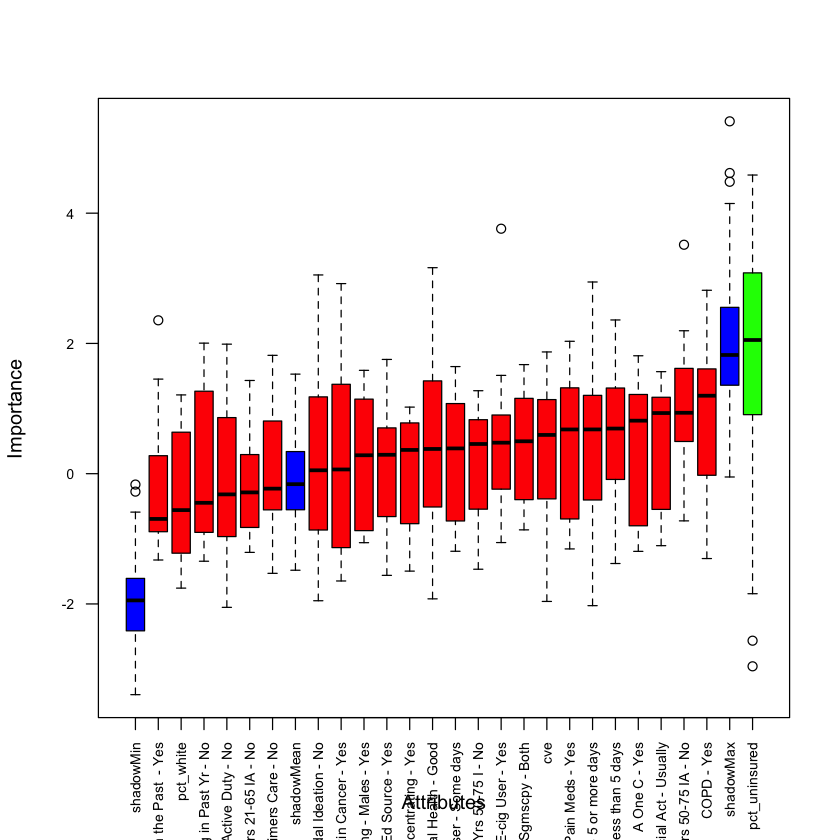

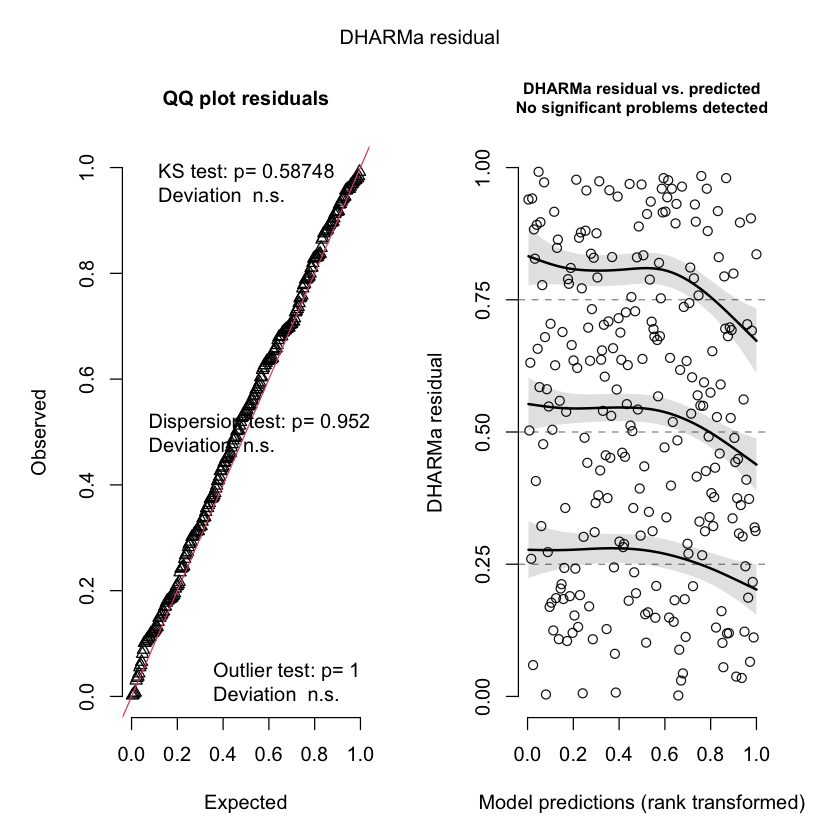

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BRFSS Variable Selection Pipeline
# Outcome: CVE rate (county-level vaccine exemption rate, 0–100)
# Model:   Beta regression with PHR random intercept via glmmTMB
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(Boruta)
library(DHARMa)


# ── 0. Helper: Smithson & Verkuilen (2006) proportion transformation ─────────
# Beta regression requires y ∈ (0, 1) strictly — no exact 0s or 1s.
# This transformation compresses [0, 1] to (0, 1) using sample size n.
sv_transform <- function(y, n = length(y)) {
  (y * (n - 1) + 0.5) / n
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Data Loading & Merging
# ══════════════════════════════════════════════════════════════════════════════

county <- read_csv("data/county_data.csv")
census <- read_csv("data/texas_census.csv")
brfss  <- read_csv("data/brfss_all_categories.csv")  # Sheet = "Indicator - Category"

# Join census to county (both county-level)
df <- county %>%
  left_join(census, by = "County")

# Transpose BRFSS from wide-by-PHR to one row per PHR.
# "R" = suppressed (small sample, unreliable) → NA
# "N" = not asked in this PHR (structural)      → NA
# Both become NA numerically, but we track R-counts to pre-filter sparse indicators.
MIN_VALID_PHR <- 7   # drop any indicator with fewer than this many non-NA PHRs

brfss_long <- brfss %>%
  mutate(across(-Sheet, ~ na_if(as.character(.), "N")),
         across(-Sheet, ~ na_if(as.character(.), "R")))

# Count valid PHRs per indicator
valid_phr_counts <- brfss_long %>%
  rowwise() %>%
  mutate(n_valid = sum(!is.na(c_across(-Sheet)))) %>%
  ungroup() %>%
  select(Sheet, n_valid)

kept_indicators <- valid_phr_counts %>%
  filter(n_valid >= MIN_VALID_PHR) %>%
  pull(Sheet)

cat("BRFSS indicators before pre-filter:", nrow(brfss_long), "\n")
cat("BRFSS indicators after pre-filter  (≥", MIN_VALID_PHR, "valid PHRs):",
    length(kept_indicators), "\n")

brfss_wide <- brfss_long %>%
  filter(Sheet %in% kept_indicators) %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Join BRFSS (PHR-level) to county data
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")
write_csv(df_final, "data/combined_data.csv")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Outcome & Covariate Preparation
# ══════════════════════════════════════════════════════════════════════════════

df <- df_final

# Outcome: outbreak count; offset: log(enrollment)
cat("Outbreak zeros:", sum(df$outbreak == 0, na.rm = TRUE), "/", sum(!is.na(df$outbreak)), "\n")

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# Build covariate matrix — cve included as predictor alongside BRFSS/census vars
X_all <- df %>%
  select(-County, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Spearman Screen  (p < 0.20)
# ══════════════════════════════════════════════════════════════════════════════

spearman_screen <- function(X, y, threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Collinearity Filter  (|r| > 0.70)
# ══════════════════════════════════════════════════════════════════════════════

X_cand     <- X_all[, candidates$variable, drop = FALSE]
cor_mat    <- cor(X_cand, use = "pairwise.complete.obs")
to_remove  <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# Remove rows where outcome or offset is NA
valid            <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)
outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Variable Selection — Boruta → LASSO
# ══════════════════════════════════════════════════════════════════════════════

# ── 5a. Boruta ───────────────────────────────────────────────────────────────
set.seed(42)
boruta_fit   <- Boruta(x = X_filtered_clean, y = outcome_clean, maxRuns = 100)
boruta_final <- TentativeRoughFix(boruta_fit)
print(boruta_final)
plot(boruta_final, las = 2, cex.axis = 0.7)

boruta_vars <- getSelectedAttributes(boruta_final, withTentative = FALSE)
cat("Boruta selected:", length(boruta_vars), "variables\n")
print(boruta_vars)

# ── 5b. LASSO on Boruta-selected variables (Poisson with offset) ─────────────
X_boruta <- model.matrix(~ . - 1,
                         data = X_filtered_clean[, boruta_vars, drop = FALSE])

if (ncol(X_boruta) < 2) {
  # Too few variables for LASSO — skip, keep whatever Boruta selected
  message("Fewer than 2 Boruta-selected variables; skipping LASSO, keeping Boruta selection.")
  final_vars <- boruta_vars
} else {
  set.seed(42)
  cv_lasso <- cv.glmnet(
    x      = X_boruta,
    y      = outcome_clean,
    offset = offset_clean,
    family = "poisson",
    alpha  = 1
  )
  plot(cv_lasso)

  lasso_coef <- coef(cv_lasso, s = "lambda.1se")
  final_vars <- rownames(lasso_coef)[
    lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
  ]
}

cat("Final selected vars (Boruta + LASSO):", length(final_vars), "\n")
print(final_vars)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Final Model — Negative Binomial with PHR Random Intercept
# ══════════════════════════════════════════════════════════════════════════════

# outbreak ~ cve + selected_vars + offset(log(enrollment)) + (1|PHR)
# nbinom2: NB with quadratic variance (more flexible than Poisson)

if (length(final_vars) == 0) {
  message("No covariates survived selection beyond cve. Fitting cve-only model.")
  model_df <- tibble(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    cve        = X_filtered_clean[["cve"]],
    PHR        = factor(PHR_clean)
  )
  fit_final <- glmmTMB(outbreak ~ cve + offset(log(enrollment)) + (1 | PHR),
                       data   = model_df,
                       family = nbinom2())
} else {
  model_df <- bind_cols(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    PHR        = factor(PHR_clean),
    X_filtered_clean[, union("cve", final_vars), drop = FALSE]
  )
  formula_final <- as.formula(paste(
    "outbreak ~",
    paste(paste0("`", union("cve", final_vars), "`"), collapse = " + "),
    "+ offset(log(enrollment)) + (1 | PHR)"
  ))
  fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
}

summary(fit_final)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Diagnostics
# ══════════════════════════════════════════════════════════════════════════════

sim <- simulateResiduals(fit_final)
plot(sim)

Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (7): pct_hispanic, pct_black, pct_white, pct_poverty, pct_uninsured, pct...
lgl (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 392 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (12): Sheet, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show

BRFSS indicators before pre-filter: 392 
BRFSS indicators after pre-filter  (<U+2265> 7 valid PHRs): 309 
Rows: 254
Columns: 322
$ County                                                     <chr> "Anderson",~
$ cve                                                        <dbl> 2.54, 1.91,~
$ outbreak                                                   <dbl> 0, 3, 0, 0,~
$ enrollment                                                 <dbl> 7808, 4209,~
$ PHR                                                        <dbl> 4, 9, 5, 11~
$ pct_hispanic                                               <dbl> 19.6, 57.5,~
$ pct_black                                                  <dbl> 18.6, 1.6, ~
$ pct_white                                                  <dbl> 58.3, 57.7,~
$ pct_poverty                                                <dbl> 13.5, 14.2,~
$ pct_uninsured                                              <dbl> 18.5, 22.4,~
$ pct_college                                                <dbl> 15.4

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 199 candidates
# A tibble: 199 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 18

Fewer than 2 Boruta-selected variables; skipping LASSO, keeping Boruta selection.



Final selected vars (Boruta + LASSO): 1 
[1] "pct_uninsured"


 Family: nbinom2  ( log )
Formula:          
outbreak ~ pct_uninsured + offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    382.2     396.3    -187.1     374.2       245 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 9.329    3.054   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.143 

Conditional model:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -13.73310    1.42677  -9.625   <2e-16 ***
pct_uninsured   0.15413    0.04722   3.264   0.0011 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

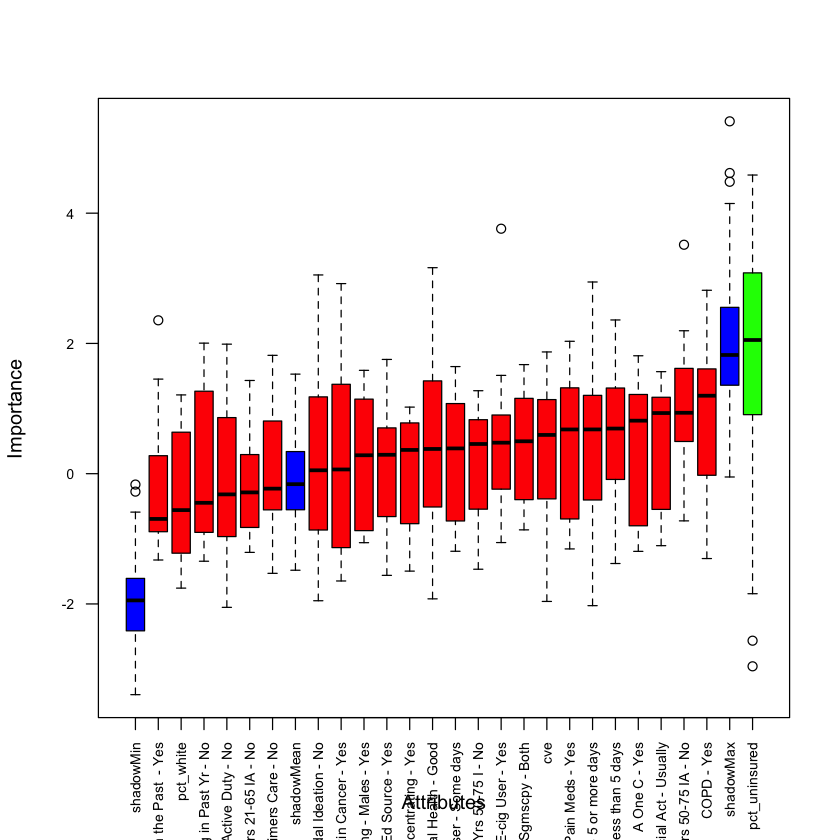

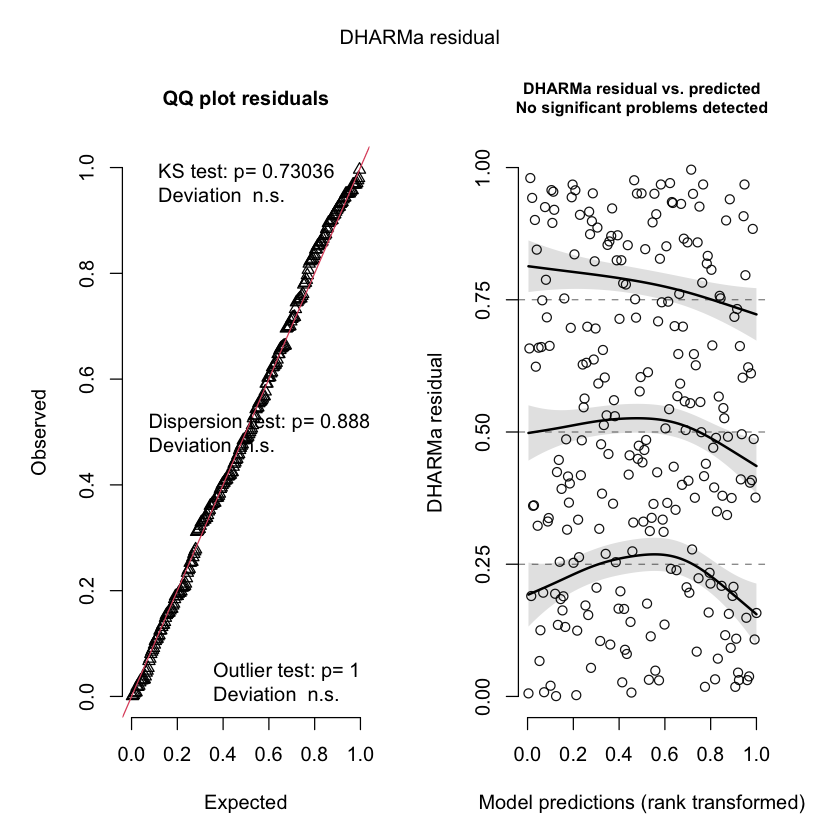

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BRFSS Variable Selection Pipeline
# Outcome: CVE rate (county-level vaccine exemption rate, 0–100)
# Model:   Beta regression with PHR random intercept via glmmTMB
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(Boruta)
library(DHARMa)


# ── 0. Helper: Smithson & Verkuilen (2006) proportion transformation ─────────
# Beta regression requires y ∈ (0, 1) strictly — no exact 0s or 1s.
# This transformation compresses [0, 1] to (0, 1) using sample size n.
sv_transform <- function(y, n = length(y)) {
  (y * (n - 1) + 0.5) / n
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Data Loading & Merging
# ══════════════════════════════════════════════════════════════════════════════

county <- read_csv("data/county_data.csv")
census <- read_csv("data/texas_census.csv")
brfss  <- read_csv("data/brfss_all_categories.csv")  # Sheet = "Indicator - Category"

# Join census to county (both county-level)
df <- county %>%
  left_join(census, by = "County")

# Transpose BRFSS from wide-by-PHR to one row per PHR.
# "R" = suppressed (small sample, unreliable) → NA
# "N" = not asked in this PHR (structural)      → NA
# Both become NA numerically, but we track R-counts to pre-filter sparse indicators.
MIN_VALID_PHR <- 7   # drop any indicator with fewer than this many non-NA PHRs

brfss_long <- brfss %>%
  mutate(across(-Sheet, ~ na_if(as.character(.), "N")),
         across(-Sheet, ~ na_if(as.character(.), "R")))

# Count valid PHRs per indicator
valid_phr_counts <- brfss_long %>%
  rowwise() %>%
  mutate(n_valid = sum(!is.na(c_across(-Sheet)))) %>%
  ungroup() %>%
  select(Sheet, n_valid)

kept_indicators <- valid_phr_counts %>%
  filter(n_valid >= MIN_VALID_PHR) %>%
  pull(Sheet)

cat("BRFSS indicators before pre-filter:", nrow(brfss_long), "\n")
cat("BRFSS indicators after pre-filter  (≥", MIN_VALID_PHR, "valid PHRs):",
    length(kept_indicators), "\n")

brfss_wide <- brfss_long %>%
  filter(Sheet %in% kept_indicators) %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Join BRFSS (PHR-level) to county data
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")
write_csv(df_final, "data/combined_data.csv")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Outcome & Covariate Preparation
# ══════════════════════════════════════════════════════════════════════════════

df <- df_final

# Outcome: outbreak count; offset: log(enrollment)
cat("Outbreak zeros:", sum(df$outbreak == 0, na.rm = TRUE), "/", sum(!is.na(df$outbreak)), "\n")

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# Build covariate matrix — cve included as predictor alongside BRFSS/census vars
X_all <- df %>%
  select(-County, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Spearman Screen  (p < 0.20)
# ══════════════════════════════════════════════════════════════════════════════

spearman_screen <- function(X, y, threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Collinearity Filter  (|r| > 0.70)
# ══════════════════════════════════════════════════════════════════════════════

X_cand     <- X_all[, candidates$variable, drop = FALSE]
cor_mat    <- cor(X_cand, use = "pairwise.complete.obs")
to_remove  <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# Remove rows where outcome or offset is NA
valid            <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)
outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Variable Selection — Boruta → LASSO
# ══════════════════════════════════════════════════════════════════════════════

# ── 5a. Boruta ───────────────────────────────────────────────────────────────
set.seed(42)
boruta_fit   <- Boruta(x = X_filtered_clean, y = outcome_clean, maxRuns = 100)
boruta_final <- TentativeRoughFix(boruta_fit)
print(boruta_final)
plot(boruta_final, las = 2, cex.axis = 0.7)

boruta_vars <- getSelectedAttributes(boruta_final, withTentative = FALSE)
cat("Boruta selected:", length(boruta_vars), "variables\n")
print(boruta_vars)

# ── 5b. LASSO on Boruta-selected variables (Poisson with offset) ─────────────
X_boruta <- model.matrix(~ . - 1,
                         data = X_filtered_clean[, boruta_vars, drop = FALSE])

if (ncol(X_boruta) < 2) {
  # Too few variables for LASSO — skip, keep whatever Boruta selected
  message("Fewer than 2 Boruta-selected variables; skipping LASSO, keeping Boruta selection.")
  final_vars <- boruta_vars
} else {
  set.seed(42)
  cv_lasso <- cv.glmnet(
    x      = X_boruta,
    y      = outcome_clean,
    offset = offset_clean,
    family = "poisson",
    alpha  = 1
  )
  plot(cv_lasso)

  lasso_coef <- coef(cv_lasso, s = "lambda.1se")
  final_vars <- rownames(lasso_coef)[
    lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
  ]
}

cat("Final selected vars (Boruta + LASSO):", length(final_vars), "\n")
print(final_vars)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Final Model — Negative Binomial with PHR Random Intercept
# ══════════════════════════════════════════════════════════════════════════════

# outbreak ~ cve + selected_vars + offset(log(enrollment)) + (1|PHR)
# nbinom2: NB with quadratic variance (more flexible than Poisson)

if (length(final_vars) == 0) {
  message("No covariates survived selection. Fitting intercept-only model.")
  model_df <- tibble(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    PHR        = factor(PHR_clean)
  )
  fit_final <- glmmTMB(outbreak ~ 1 + offset(log(enrollment)) + (1 | PHR),
                       data   = model_df,
                       family = nbinom2())
} else {
  model_df <- bind_cols(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    PHR        = factor(PHR_clean),
    X_filtered_clean[, final_vars, drop = FALSE]
  )
  formula_final <- as.formula(paste(
    "outbreak ~",
    paste(paste0("`", final_vars, "`"), collapse = " + "),
    "+ offset(log(enrollment)) + (1 | PHR)"
  ))
  fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
}

summary(fit_final)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Diagnostics
# ══════════════════════════════════════════════════════════════════════════════

sim <- simulateResiduals(fit_final)
plot(sim)

Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (7): pct_hispanic, pct_black, pct_white, pct_poverty, pct_uninsured, pct...
lgl (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 392 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (12): Sheet, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show

BRFSS indicators before pre-filter: 392 
BRFSS indicators after pre-filter  (<U+2265> 7 valid PHRs): 309 
Rows: 254
Columns: 322
$ County                                                     <chr> "Anderson",~
$ cve                                                        <dbl> 2.54, 1.91,~
$ outbreak                                                   <dbl> 0, 3, 0, 0,~
$ enrollment                                                 <dbl> 7808, 4209,~
$ PHR                                                        <dbl> 4, 9, 5, 11~
$ pct_hispanic                                               <dbl> 19.6, 57.5,~
$ pct_black                                                  <dbl> 18.6, 1.6, ~
$ pct_white                                                  <dbl> 58.3, 57.7,~
$ pct_poverty                                                <dbl> 13.5, 14.2,~
$ pct_uninsured                                              <dbl> 18.5, 22.4,~
$ pct_college                                                <dbl> 15.4

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 210 candidates
# A tibble: 210 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 20

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Current E-cig User - Yes` + `ClnscpySgmscpy - Both` +  
    `Served on Active Duty - No` + `RxPainRiskEd Source - Yes` +  
    `COPD - Yes` + pct_uninsured + `Difficulty Concentrating - Yes` +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    372.0     410.7    -175.0     350.0       238 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev.
 PHR    (Intercept) 7.744e-09 8.8e-05 
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.158 

Conditional model:
                                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)                      -36.04001   10.87002  -3.316 0.000915 ***
cve                                0.39251    0.17413   2.254 0.024190 *  
`Current E-cig User - Yes`         0.68698    0.20629   3.330 0.000868 ***
`ClnscpySgmscpy - Both`           -0.42927    0.19103  -2.24

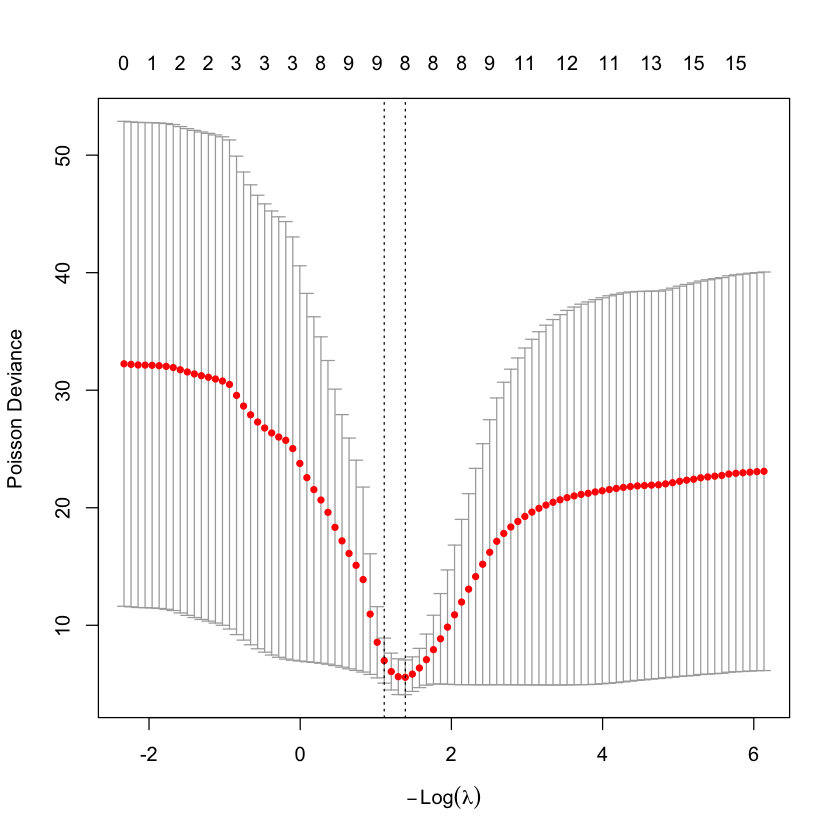

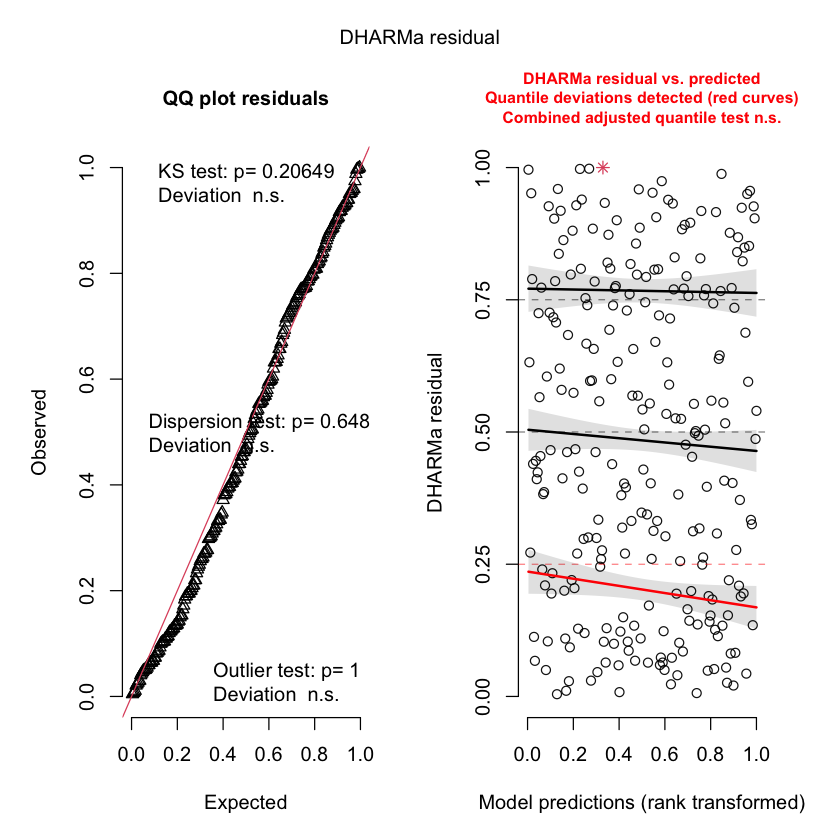

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BRFSS Variable Selection Pipeline
# Outcome: CVE rate (county-level vaccine exemption rate, 0–100)
# Model:   Beta regression with PHR random intercept via glmmTMB
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(Boruta)
library(DHARMa)


# ── 0. Helper: Smithson & Verkuilen (2006) proportion transformation ─────────
# Beta regression requires y ∈ (0, 1) strictly — no exact 0s or 1s.
# This transformation compresses [0, 1] to (0, 1) using sample size n.
sv_transform <- function(y, n = length(y)) {
  (y * (n - 1) + 0.5) / n
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Data Loading & Merging
# ══════════════════════════════════════════════════════════════════════════════

county <- read_csv("data/county_data.csv")
census <- read_csv("data/texas_census.csv")
brfss  <- read_csv("data/brfss_all_categories.csv")  # Sheet = "Indicator - Category"

# Join census to county (both county-level)
df <- county %>%
  left_join(census, by = "County")

# Transpose BRFSS from wide-by-PHR to one row per PHR.
# "R" = suppressed (small sample, unreliable) → NA
# "N" = not asked in this PHR (structural)      → NA
# Both become NA numerically, but we track R-counts to pre-filter sparse indicators.
MIN_VALID_PHR <- 7   # drop any indicator with fewer than this many non-NA PHRs

brfss_long <- brfss %>%
  mutate(across(-Sheet, ~ na_if(as.character(.), "N")),
         across(-Sheet, ~ na_if(as.character(.), "R")))

# Count valid PHRs per indicator
valid_phr_counts <- brfss_long %>%
  rowwise() %>%
  mutate(n_valid = sum(!is.na(c_across(-Sheet)))) %>%
  ungroup() %>%
  select(Sheet, n_valid)

kept_indicators <- valid_phr_counts %>%
  filter(n_valid >= MIN_VALID_PHR) %>%
  pull(Sheet)

cat("BRFSS indicators before pre-filter:", nrow(brfss_long), "\n")
cat("BRFSS indicators after pre-filter  (≥", MIN_VALID_PHR, "valid PHRs):",
    length(kept_indicators), "\n")

brfss_wide <- brfss_long %>%
  filter(Sheet %in% kept_indicators) %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Join BRFSS (PHR-level) to county data
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")
write_csv(df_final, "data/combined_data.csv")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Outcome & Covariate Preparation
# ══════════════════════════════════════════════════════════════════════════════

df <- df_final

# Outcome: outbreak count; offset: log(enrollment)
cat("Outbreak zeros:", sum(df$outbreak == 0, na.rm = TRUE), "/", sum(!is.na(df$outbreak)), "\n")

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# Build covariate matrix — cve included as predictor alongside BRFSS/census vars
X_all <- df %>%
  select(-County, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Spearman Screen  (p < 0.20)
# ══════════════════════════════════════════════════════════════════════════════

spearman_screen <- function(X, y, threshold = 0.3) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Collinearity Filter  (|r| > 0.70)
# ══════════════════════════════════════════════════════════════════════════════

X_cand     <- X_all[, candidates$variable, drop = FALSE]
cor_mat    <- cor(X_cand, use = "pairwise.complete.obs")
to_remove  <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# Remove rows where outcome or offset is NA
valid            <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)
outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Variable Selection — Boruta → LASSO
# ══════════════════════════════════════════════════════════════════════════════

# ── 5. LASSO on all collinearity-filtered variables ──────────────────────────
X_mat <- model.matrix(~ . - 1, data = X_filtered_clean)

set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = outcome_clean,
  offset = offset_clean,
  family = "poisson",
  alpha  = 1
)
plot(cv_lasso)

lasso_coef <- coef(cv_lasso, s = "lambda.min")
final_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
# model.matrix adds backticks to names with spaces — strip them
final_vars <- gsub("^`|`$", "", final_vars)
# keep only vars that actually exist in X_filtered_clean
final_vars <- final_vars[final_vars %in% names(X_filtered_clean)]

cat("Final selected vars (LASSO):", length(final_vars), "\n")
print(final_vars)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Final Model — Negative Binomial with PHR Random Intercept
# ══════════════════════════════════════════════════════════════════════════════

# outbreak ~ cve + selected_vars + offset(log(enrollment)) + (1|PHR)
# nbinom2: NB with quadratic variance (more flexible than Poisson)

if (length(final_vars) == 0) {
  message("No covariates survived selection. Fitting cve-only model.")
  model_df <- tibble(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    cve        = X_filtered_clean[["cve"]],
    PHR        = factor(PHR_clean)
  )
  fit_final <- glmmTMB(outbreak ~ cve + offset(log(enrollment)) + (1 | PHR),
                       data   = model_df,
                       family = nbinom2())
} else {
  keep_vars <- union("cve", final_vars)
  model_df  <- bind_cols(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    PHR        = factor(PHR_clean),
    X_filtered_clean[, keep_vars, drop = FALSE]
  )
  formula_final <- as.formula(paste(
    "outbreak ~",
    paste(paste0("`", keep_vars, "`"), collapse = " + "),
    "+ offset(log(enrollment)) + (1 | PHR)"
  ))
  fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
}

summary(fit_final)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Diagnostics
# ══════════════════════════════════════════════════════════════════════════════

sim <- simulateResiduals(fit_final)
plot(sim)

Rows: 254 Columns: 5
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (4): cve, outbreak, enrollment, PHR

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 254 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (7): pct_hispanic, pct_black, pct_white, pct_poverty, pct_uninsured, pct...
lgl (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 392 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (12): Sheet, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show

BRFSS indicators before pre-filter: 392 
BRFSS indicators after pre-filter  (<U+2265> 7 valid PHRs): 309 
Rows: 254
Columns: 322
$ County                                                     <chr> "Anderson",~
$ cve                                                        <dbl> 2.54, 1.91,~
$ outbreak                                                   <dbl> 0, 3, 0, 0,~
$ enrollment                                                 <dbl> 7808, 4209,~
$ PHR                                                        <dbl> 4, 9, 5, 11~
$ pct_hispanic                                               <dbl> 19.6, 57.5,~
$ pct_black                                                  <dbl> 18.6, 1.6, ~
$ pct_white                                                  <dbl> 58.3, 57.7,~
$ pct_poverty                                                <dbl> 13.5, 14.2,~
$ pct_uninsured                                              <dbl> 18.5, 22.4,~
$ pct_college                                                <dbl> 15.4

Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"


After Spearman screen: 210 candidates
# A tibble: 210 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 20

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Current E-cig User - Yes` + `ClnscpySgmscpy - Both` +  
    `Served on Active Duty - No` + `RxPainRiskEd Source - Yes` +  
    `COPD - Yes` + pct_uninsured + `Difficulty Concentrating - Yes` +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    372.0     410.7    -175.0     350.0       238 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev.
 PHR    (Intercept) 7.744e-09 8.8e-05 
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.158 

Conditional model:
                                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)                      -36.04001   10.87002  -3.316 0.000915 ***
cve                                0.39251    0.17413   2.254 0.024190 *  
`Current E-cig User - Yes`         0.68698    0.20629   3.330 0.000868 ***
`ClnscpySgmscpy - Both`           -0.42927    0.19103  -2.24

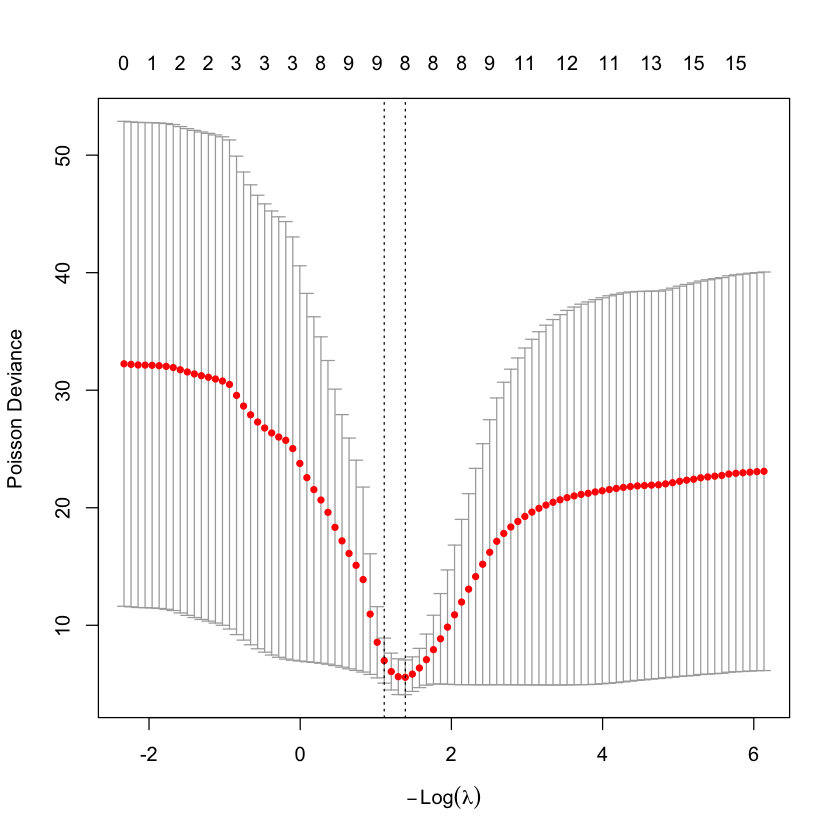

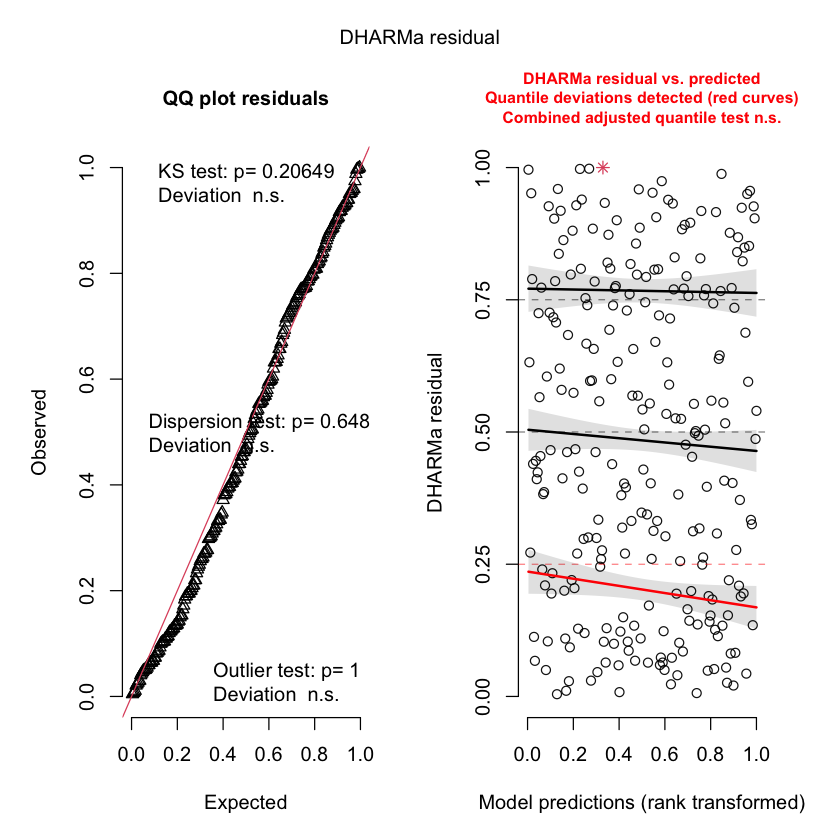

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# BRFSS Variable Selection Pipeline
# Outcome: CVE rate (county-level vaccine exemption rate, 0–100)
# Model:   Beta regression with PHR random intercept via glmmTMB
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(Boruta)
library(DHARMa)


# ── 0. Helper: Smithson & Verkuilen (2006) proportion transformation ─────────
# Beta regression requires y ∈ (0, 1) strictly — no exact 0s or 1s.
# This transformation compresses [0, 1] to (0, 1) using sample size n.
sv_transform <- function(y, n = length(y)) {
  (y * (n - 1) + 0.5) / n
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Data Loading & Merging
# ══════════════════════════════════════════════════════════════════════════════

county <- read_csv("data/county_data.csv")
census <- read_csv("data/texas_census.csv")
brfss  <- read_csv("data/brfss_all_categories.csv")  # Sheet = "Indicator - Category"

# Join census to county (both county-level)
df <- county %>%
  left_join(census, by = "County")

# Transpose BRFSS from wide-by-PHR to one row per PHR.
# "R" = suppressed (small sample, unreliable) → NA
# "N" = not asked in this PHR (structural)      → NA
# Both become NA numerically, but we track R-counts to pre-filter sparse indicators.
MIN_VALID_PHR <- 7   # drop any indicator with fewer than this many non-NA PHRs

brfss_long <- brfss %>%
  mutate(across(-Sheet, ~ na_if(as.character(.), "N")),
         across(-Sheet, ~ na_if(as.character(.), "R")))

# Count valid PHRs per indicator
valid_phr_counts <- brfss_long %>%
  rowwise() %>%
  mutate(n_valid = sum(!is.na(c_across(-Sheet)))) %>%
  ungroup() %>%
  select(Sheet, n_valid)

kept_indicators <- valid_phr_counts %>%
  filter(n_valid >= MIN_VALID_PHR) %>%
  pull(Sheet)

cat("BRFSS indicators before pre-filter:", nrow(brfss_long), "\n")
cat("BRFSS indicators after pre-filter  (≥", MIN_VALID_PHR, "valid PHRs):",
    length(kept_indicators), "\n")

brfss_wide <- brfss_long %>%
  filter(Sheet %in% kept_indicators) %>%
  column_to_rownames("Sheet") %>%
  t() %>%
  as.data.frame() %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  rownames_to_column("phr_label") %>%
  mutate(PHR = as.integer(str_extract(phr_label, "\\d+"))) %>%
  select(-phr_label)

# Join BRFSS (PHR-level) to county data
df_final <- df %>%
  left_join(brfss_wide, by = "PHR")

glimpse(df_final)
cat("Rows:", nrow(df_final), "| Cols:", ncol(df_final), "\n")
write_csv(df_final, "data/combined_data.csv")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Outcome & Covariate Preparation
# ══════════════════════════════════════════════════════════════════════════════

df <- df_final

# Outcome: outbreak count; offset: log(enrollment)
cat("Outbreak zeros:", sum(df$outbreak == 0, na.rm = TRUE), "/", sum(!is.na(df$outbreak)), "\n")

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# Build covariate matrix — cve included as predictor alongside BRFSS/census vars
X_all <- df %>%
  select(-County, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Spearman Screen  (p < 0.20)
# ══════════════════════════════════════════════════════════════════════════════

spearman_screen <- function(X, y, threshold = 0.3) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Collinearity Filter  (|r| > 0.70)
# ══════════════════════════════════════════════════════════════════════════════

X_cand     <- X_all[, candidates$variable, drop = FALSE]
cor_mat    <- cor(X_cand, use = "pairwise.complete.obs")
to_remove  <- findCorrelation(cor_mat, cutoff = 0.7, names = TRUE)
X_filtered <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filtered), "variables\n")

# Remove rows where outcome or offset is NA
valid            <- !is.na(outcome) & !is.na(offset_var) & is.finite(offset_var)
outcome_clean    <- outcome[valid]
offset_clean     <- offset_var[valid]
PHR_clean        <- PHR[valid]
X_filtered_clean <- X_filtered[valid, , drop = FALSE]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Variable Selection — Boruta → LASSO
# ══════════════════════════════════════════════════════════════════════════════

# ── 5. LASSO on all collinearity-filtered variables ──────────────────────────
X_mat <- model.matrix(~ . - 1, data = X_filtered_clean)

set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = outcome_clean,
  offset = offset_clean,
  family = "poisson",
  alpha  = 1
)
plot(cv_lasso)

lasso_coef <- coef(cv_lasso, s = "lambda.1se")
final_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
# model.matrix adds backticks to names with spaces — strip them
final_vars <- gsub("^`|`$", "", final_vars)
# keep only vars that actually exist in X_filtered_clean
final_vars <- final_vars[final_vars %in% names(X_filtered_clean)]

cat("Final selected vars (LASSO):", length(final_vars), "\n")
print(final_vars)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Final Model — Negative Binomial with PHR Random Intercept
# ══════════════════════════════════════════════════════════════════════════════

# outbreak ~ cve + selected_vars + offset(log(enrollment)) + (1|PHR)
# nbinom2: NB with quadratic variance (more flexible than Poisson)

if (length(final_vars) == 0) {
  message("No covariates survived selection. Fitting cve-only model.")
  model_df <- tibble(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    cve        = X_filtered_clean[["cve"]],
    PHR        = factor(PHR_clean)
  )
  fit_final <- glmmTMB(outbreak ~ cve + offset(log(enrollment)) + (1 | PHR),
                       data   = model_df,
                       family = nbinom2())
} else {
  keep_vars <- union("cve", final_vars)
  model_df  <- bind_cols(
    outbreak   = outcome_clean,
    enrollment = exp(offset_clean),
    PHR        = factor(PHR_clean),
    X_filtered_clean[, keep_vars, drop = FALSE]
  )
  formula_final <- as.formula(paste(
    "outbreak ~",
    paste(paste0("`", keep_vars, "`"), collapse = " + "),
    "+ offset(log(enrollment)) + (1 | PHR)"
  ))
  fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
}

summary(fit_final)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Diagnostics
# ══════════════════════════════════════════════════════════════════════════════

sim <- simulateResiduals(fit_final)
plot(sim)